In [23]:
import polars as pl
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

trips_df = pl.read_parquet('yellow_tripdata_2026_clean.parquet')
zones_df = pl.read_csv('taxi_zone_lookup.csv')

print(f"Dimensiones del dataset de viajes: {trips_df.shape}")
display(trips_df.head())

Dimensiones del dataset de viajes: (10463178, 17)


VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,PULocationID,DOLocationID,pu_borough,pu_zone,pu_service_zone,do_borough,do_zone,do_service_zone,trip_distance,fare_amount,trip_duration_minutes,pickup_hour,pickup_day_of_week,pickup_month
i32,"datetime[μs, UTC]","datetime[μs, UTC]",i32,i32,str,str,str,str,str,str,f64,f64,i64,i32,i32,i32
2,2026-01-01 00:54:04 UTC,2026-01-01 00:59:37 UTC,239,238,"""Manhattan""","""Upper West Side South""","""Yellow Zone""","""Manhattan""","""Upper West Side North""","""Yellow Zone""",0.97,7.2,5,19,3,12
1,2026-01-01 00:34:04 UTC,2026-01-01 00:39:47 UTC,163,162,"""Manhattan""","""Midtown North""","""Yellow Zone""","""Manhattan""","""Midtown East""","""Yellow Zone""",0.9,7.9,5,19,3,12
1,2026-01-01 00:57:06 UTC,2026-01-01 01:05:59 UTC,43,237,"""Manhattan""","""Central Park""","""Yellow Zone""","""Manhattan""","""Upper East Side South""","""Yellow Zone""",1.4,10.7,8,19,3,12
2,2026-01-01 00:15:22 UTC,2026-01-01 00:58:10 UTC,142,209,"""Manhattan""","""Lincoln Square East""","""Yellow Zone""","""Manhattan""","""Seaport""","""Yellow Zone""",5.58,38.7,42,19,3,12
2,2026-01-01 00:27:13 UTC,2026-01-01 00:40:43 UTC,88,144,"""Manhattan""","""Financial District South""","""Yellow Zone""","""Manhattan""","""Little Italy/NoLiTa""","""Yellow Zone""",2.16,13.5,13,19,3,12


In [24]:
# 1. Preparación de Datos

# Tomamos la muestra y aseguramos que los Boroughs estén presentes
zones_pl = pl.from_pandas(zones_df) if isinstance(zones_df, pd.DataFrame) else zones_df

trips_with_names = trips_df
if 'pu_borough' not in trips_with_names.columns:
    pu_zones = zones_pl.select([pl.col('LocationID'), pl.col('Borough').alias('pu_borough')])
    trips_with_names = trips_with_names.join(pu_zones, left_on='PULocationID', right_on='LocationID', how='left')

if 'do_borough' not in trips_with_names.columns:
    do_zones = zones_pl.select([pl.col('LocationID'), pl.col('Borough').alias('do_borough')])
    trips_with_names = trips_with_names.join(do_zones, left_on='DOLocationID', right_on='LocationID', how='left')

sample_raw = trips_with_names.sample(n=200_000, seed=42).to_pandas()

# Convertimos a categorías numéricas para que el modelo pueda procesar el texto
for col in ['pu_borough', 'do_borough']:
    sample_raw[col] = sample_raw[col].astype('category').cat.codes

In [25]:
# 2. Selección de Características con RFECV
from sklearn.feature_selection import RFECV
from sklearn.model_selection import KFold
from sklearn.ensemble import RandomForestRegressor
import pandas as pd

# Excluimos VendorID y variables de alta cardinalidad/fechas/IDs directos
exclude = ['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime', 'trip_duration_minutes',
           'store_and_fwd_flag', 'PULocationID', 'DOLocationID', 'pu_zone', 'do_zone', 'pu_service_zone', 'do_service_zone']
candidate_features = [col for col in sample_raw.columns if col not in exclude]

X_opt = sample_raw[candidate_features].fillna(0)
y_opt = sample_raw['trip_duration_minutes'].fillna(0)

# Estimador base
rf = RandomForestRegressor(n_estimators=10, max_depth=5, n_jobs=-1, random_state=42)

print(f"Iniciando RFECV con variables: {candidate_features}")
selector = RFECV(estimator=rf, step=1, cv=KFold(3), scoring='neg_mean_squared_error', n_jobs=-1)
selector.fit(X_opt, y_opt)

print(f"Proceso completado. Numero optimo de variables: {selector.n_features_}")
print("Variables seleccionadas:", X_opt.columns[selector.support_].tolist())

Iniciando RFECV con variables: ['pu_borough', 'do_borough', 'trip_distance', 'fare_amount', 'pickup_hour', 'pickup_day_of_week', 'pickup_month']
Proceso completado. Numero optimo de variables: 5
Variables seleccionadas: ['pu_borough', 'trip_distance', 'fare_amount', 'pickup_hour', 'pickup_day_of_week']


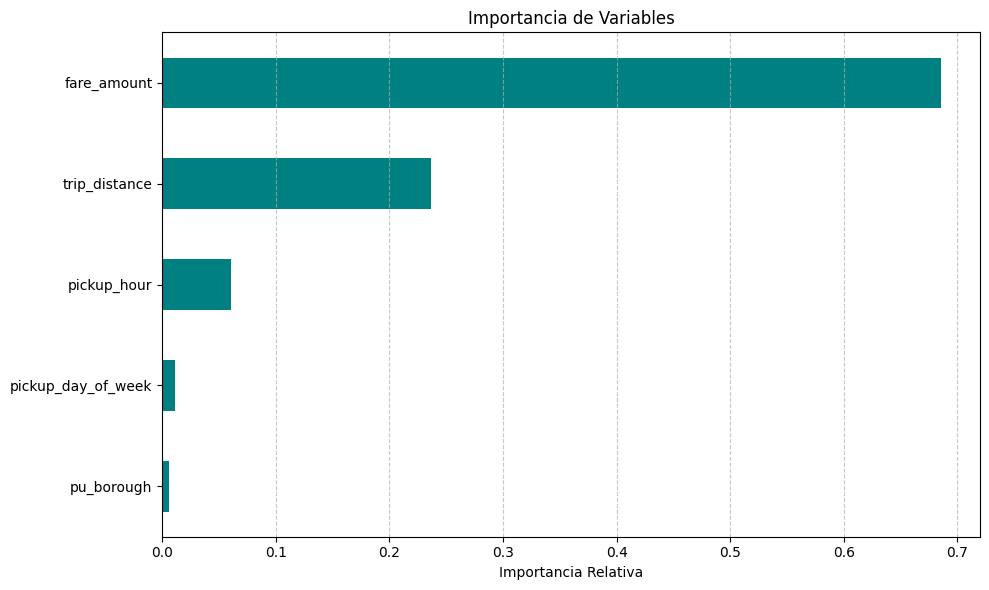

In [27]:
# 3. Visualización de Resultados

selected_features = X_opt.columns[selector.support_].tolist()
importances = pd.Series(selector.estimator_.feature_importances_, index=selected_features)

plt.figure(figsize=(10, 6))
importances.sort_values().plot(kind='barh', color='teal')
plt.title('Importancia de Variables')
plt.xlabel('Importancia Relativa')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [28]:
# Resumen de importancia (Actualizado)
selected_features = X_opt.columns[selector.support_].tolist()
final_importance = pd.Series(selector.estimator_.feature_importances_, index=selected_features)

print(final_importance.sort_values(ascending=False))

fare_amount           0.685573
trip_distance         0.236687
pickup_hour           0.060311
pickup_day_of_week    0.011092
pu_borough            0.006338
dtype: float64
